## 1. Planteamiento del Proyecto

### Guía para exponer esta sección

**Qué decir:**
- Este proyecto aborda un problema de bienestar laboral con impacto organizacional: el burnout y la deserción.
- La meta no es solo describir datos, sino generar evidencia útil para prevención temprana en RRHH.

**Conexión con la problemática:**
- Si una empresa detecta tarde el agotamiento, ya enfrenta baja productividad, ausentismo o renuncias.
- Por eso necesitamos un enfoque analítico que anticipe señales de riesgo.

# Predicción del Riesgo de Burnout y Abandono Laboral
## Proyecto Final - Bootcamp Análisis de Datos

Este cuaderno presenta un análisis exploratorio del dataset AI Worker Risk (Kaggle) para responder la pregunta central del proyecto:

**¿Es posible anticipar el riesgo de burnout y de abandono laboral a partir de variables laborales, tecnológicas y de satisfacción del empleado?**

### Estructura narrativa de la exposición
1. Comprender la calidad y composición de los datos.
2. Describir la magnitud del riesgo de burnout/attrition.
3. Identificar relaciones entre variables que expliquen el fenómeno.
4. Traducir hallazgos en recomendaciones para RRHH y líderes de equipo.

### Guía para exponer esta sección

**Qué decir:**
- Esta es la pregunta que guía todo el cuaderno; cada gráfica debe responder una parte de esta pregunta.
- El objetivo es pasar de intuiciones a decisiones basadas en evidencia.

**Conexión con la problemática:**
- La documentación del proyecto destaca que el burnout se detecta de forma reactiva.
- Aquí se propone una ruta preventiva: identificar factores de riesgo antes de que escalen.

### Contexto de la problemática

El burnout es un riesgo psicosocial con impacto en salud, productividad y rotación de personal. En este proyecto, los datos se usan con enfoque preventivo: detectar señales tempranas para intervenir antes de que se materialice la renuncia o el deterioro del bienestar.

### Criterio de lectura de resultados

En cada sección se responderán tres preguntas:
- ¿Qué muestra la evidencia?
- ¿Qué implica para el problema?
- ¿Qué decisión organizacional habilita?

### Guía para exponer esta sección

**Qué decir:**
- El análisis se interpreta siempre con enfoque de decisión, no solo descriptivo.
- Cada resultado se traduce en una posible acción para stakeholders internos (RRHH, líderes y dirección).

**Conexión con la problemática:**
- Se alinea con el enfoque de la documentación: integrar evidencia técnica con impacto humano y organizacional.

## 2. Configuración del Entorno de Análisis

### Guía para exponer esta sección

**Qué decir:**
- Aquí se garantiza reproducibilidad técnica: librerías, estilo visual y entorno consistente.
- Esto permite que los resultados puedan ser auditables y repetibles.

**Conexión con la problemática:**
- Si los resultados van a respaldar decisiones de bienestar laboral, deben ser técnicamente confiables.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurar el estilo de las gráficas
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


## 3. Carga Inicial y Vista General del Dataset

### Guía para exponer esta sección

**Qué decir:**
- Se carga el dataset y se observa su estructura general para entender el universo de análisis.
- Esta revisión inicial permite validar que contamos con variables relevantes para burnout y attrition.

**Conexión con la problemática:**
- Sin una base de datos consistente, no se puede anticipar riesgo ni diseñar intervenciones preventivas.

In [40]:
# Cargar el dataset
df = pd.read_csv('ai_worker_burnout_attrition_2026.csv')

print("Primeras filas del dataset:")
print(df.head())
print("\n" + "="*80)
print("\nInformación general del dataset:")
print(df.info())


Primeras filas del dataset:
  employee_id          job_role  years_experience education_level  country  \
0     EMP0001      Data Analyst                 7             PhD    India   
1     EMP0002   DevOps Engineer                 3     Self-taught   Canada   
2     EMP0003   Prompt Engineer                 3             PhD    India   
3     EMP0004  Backend Engineer                18          Master  Germany   
4     EMP0005     AI Researcher                 5        Bachelor    India   

     industry       company_size remote_work_type  team_size  salary_usd_k  \
0  Healthtech  Large (1000-5000)     Fully Remote          8           184   
1     Fintech  Large (1000-5000)           Hybrid         42            51   
2  Automotive      Startup (<50)           Hybrid         37           185   
3       Media     Mid (200-1000)     Fully Remote          8           131   
4  E-commerce     Small (50-200)     Fully Remote         21            99   

   ... ai_tools_used_per_day  hour

## 4. Tipos de Datos y Estructura

### Guía para exponer esta sección

**Qué decir:**
- Identificamos qué variables son numéricas y cuáles categóricas para elegir métodos correctos de análisis.
- Esta clasificación evita errores de interpretación y prepara el preprocesamiento.

**Conexión con la problemática:**
- Tratar bien los tipos de datos es clave para no distorsionar señales de bienestar, satisfacción o riesgo de salida.

In [41]:
# Definición de tipos de datos
print("Tipos de datos por columna:")
print(df.dtypes)
print("\n" + "="*80)

# Crear tabla de tipos de datos
tipos_datos = pd.DataFrame({
    'Columna': df.columns,
    'Tipo de Dato': df.dtypes.values,
    'Tipo Python': df.dtypes.apply(lambda x: str(x)).values
})

print("\nResumen de tipos de datos:")
print(tipos_datos)


Tipos de datos por columna:
employee_id                        object
job_role                           object
years_experience                    int64
education_level                    object
country                            object
industry                           object
company_size                       object
remote_work_type                   object
team_size                           int64
salary_usd_k                        int64
primary_ai_tool                    object
ai_tools_used_per_day               int64
hours_with_ai_assistance_daily    float64
ai_replaces_my_tasks_pct            int64
ai_adoption_stage                  object
weekly_ai_upskilling_hrs          float64
productivity_score                  int64
burnout_score                       int64
job_satisfaction_1_5              float64
fear_of_ai_replacement             object
attrition_risk                     object
dtype: object


Resumen de tipos de datos:
                           Columna Tipo de Dato

## 5. Categorización de Variables Relevantes

### Guía para exponer esta sección

**Qué decir:**
- Aquí se organiza cada variable según su naturaleza analítica (nominal, ordinal, continua, etc.).
- Esto permite conectar variables técnicas con dimensiones humanas: carga, satisfacción, miedo y desempeño.

**Conexión con la problemática:**
- La documentación plantea un enfoque multidimensional; esta sección materializa ese enfoque en los datos.

In [42]:
# Categorización de campos
categorias = {
    'Categórico Nominal': ['employee_id', 'job_role', 'country', 'industry', 'primary_ai_tool', 'remote_work_type'],
    'Categórico Ordinal': ['education_level', 'ai_adoption_stage', 'fear_of_ai_replacement'],
    'Categórico Binario': ['attrition_risk'],
    'Numérico Discreto': ['years_experience', 'company_size', 'team_size', 'ai_tools_used_per_day'],
    'Numérico Continuo': ['salary_usd_k', 'hours_with_ai_assistance_daily', 'ai_replaces_my_tasks_pct', 
                           'weekly_ai_upskilling_hrs', 'productivity_score', 'burnout_score', 
                           'job_satisfaction_1_5']
}

print("CATEGORIZACIÓN DE CAMPOS DEL DATASET:\n")
for categoria, campos in categorias.items():
    print(f"\n{categoria}:")
    for campo in campos:
        if campo in df.columns:
            print(f"  ✓ {campo}")
        
# Crear tabla de categorización
categorias_list = []
for categoria, campos in categorias.items():
    for campo in campos:
        if campo in df.columns:
            categorias_list.append({
                'Campo': campo,
                'Categoría': categoria,
                'Tipo Dato': df[campo].dtype
            })

df_categorias = pd.DataFrame(categorias_list)
print("\n" + "="*80)
print("\nTabla de Categorización:")
print(df_categorias)


CATEGORIZACIÓN DE CAMPOS DEL DATASET:


Categórico Nominal:
  ✓ employee_id
  ✓ job_role
  ✓ country
  ✓ industry
  ✓ primary_ai_tool
  ✓ remote_work_type

Categórico Ordinal:
  ✓ education_level
  ✓ ai_adoption_stage
  ✓ fear_of_ai_replacement

Categórico Binario:
  ✓ attrition_risk

Numérico Discreto:
  ✓ years_experience
  ✓ company_size
  ✓ team_size
  ✓ ai_tools_used_per_day

Numérico Continuo:
  ✓ salary_usd_k
  ✓ hours_with_ai_assistance_daily
  ✓ ai_replaces_my_tasks_pct
  ✓ weekly_ai_upskilling_hrs
  ✓ productivity_score
  ✓ burnout_score
  ✓ job_satisfaction_1_5


Tabla de Categorización:
                             Campo           Categoría Tipo Dato
0                      employee_id  Categórico Nominal    object
1                         job_role  Categórico Nominal    object
2                          country  Categórico Nominal    object
3                         industry  Categórico Nominal    object
4                  primary_ai_tool  Categórico Nominal    object
5   

## 6. Dimensionalidad del Dataset

### Guía para exponer esta sección

**Qué decir:**
- Se reporta el tamaño del dataset para contextualizar la robustez descriptiva del análisis.
- También se muestra la escala de información con la que se trabaja.

**Conexión con la problemática:**
- Conocer la dimensionalidad permite valorar el alcance y límites de los hallazgos para la toma de decisiones.

In [43]:
# Análisis de dimensionalidad del dataset
print("ANÁLISIS DE DIMENSIONALIDAD DEL DATASET\n")
print("="*80)

# Cantidad de filas usando len()
filas_len = len(df)
print(f"\n1. Cantidad de filas usando len(): {filas_len}")

# Cantidad de filas usando shape
filas_shape = df.shape[0]
print(f"2. Cantidad de filas usando shape: {filas_shape}")

# Cantidad de columnas
columnas = df.shape[1]
print(f"3. Cantidad de columnas: {columnas}")

# Cantidad total de elementos
elementos_totales = df.shape[0] * df.shape[1]
print(f"4. Cantidad total de elementos (filas × columnas): {elementos_totales}")

print("\n" + "="*80)
print(f"\nResumen: {filas_shape} registros × {columnas} campos = {elementos_totales} elementos")


ANÁLISIS DE DIMENSIONALIDAD DEL DATASET


1. Cantidad de filas usando len(): 1500
2. Cantidad de filas usando shape: 1500
3. Cantidad de columnas: 21
4. Cantidad total de elementos (filas × columnas): 31500


Resumen: 1500 registros × 21 campos = 31500 elementos


## 7. Calidad y Limpieza de Datos

### Guía para exponer esta sección

**Qué decir:**
- Se revisan nulos, duplicados y campos que no aportan al análisis causal-descriptivo.
- Limpiar datos reduce sesgos y mejora la credibilidad de los hallazgos.

**Conexión con la problemática:**
- Decisiones sobre bienestar laboral requieren evidencia confiable; datos sucios pueden generar acciones erróneas sobre personas.

In [44]:
# Limpieza de datos
print("ANÁLISIS DE LIMPIEZA DE DATOS\n")
print("="*80)

# Verificar valores nulos
print("\n1. Valores nulos por columna:")
nulos = df.isnull().sum()
print(nulos[nulos > 0])
if nulos.sum() == 0:
    print("   ✓ No hay valores nulos en el dataset")

# Verificar duplicados
print(f"\n2. Filas duplicadas: {df.duplicated().sum()}")

# Identificar campos innecesarios (opcional)
print("\n3. Campos identificados como potencialmente innecesarios:")
print("   * 'employee_id': Identificador único (puede ser innecesario para análisis)")

# Crear una copia sin campos innecesarios (opcional)
df_limpio = df.drop(columns=['employee_id'])
print(f"\n4. Dataset limpio creado sin campos innecesarios")
print(f"   Dimensiones antes: {df.shape}")
print(f"   Dimensiones después: {df_limpio.shape}")


ANÁLISIS DE LIMPIEZA DE DATOS


1. Valores nulos por columna:
Series([], dtype: int64)
   ✓ No hay valores nulos en el dataset

2. Filas duplicadas: 0

3. Campos identificados como potencialmente innecesarios:
   * 'employee_id': Identificador único (puede ser innecesario para análisis)

4. Dataset limpio creado sin campos innecesarios
   Dimensiones antes: (1500, 21)
   Dimensiones después: (1500, 20)


## 8. Separación de Variables Numéricas y Categóricas

### Guía para exponer esta sección

**Qué decir:**
- Esta separación prepara análisis estadísticos y visualizaciones acordes al tipo de variable.
- Permite comparar niveles de riesgo y comportamientos por segmentos.

**Conexión con la problemática:**
- El burnout no depende de un solo factor; combinar variables numéricas y categóricas mejora la lectura del riesgo.

In [45]:
# Seleccionar campos numéricos y no numéricos
print("SELECCIÓN DE CAMPOS NUMÉRICOS Y NO NUMÉRICOS\n")
print("="*80)

# Campos numéricos
campos_numericos = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nCampos Numéricos ({len(campos_numericos)}):")
for campo in campos_numericos:
    print(f"  • {campo}")

# Campos no numéricos
campos_no_numericos = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"\nCampos No Numéricos ({len(campos_no_numericos)}):")
for campo in campos_no_numericos:
    print(f"  • {campo}")

# DataFrames separados
df_numericos = df[campos_numericos]
df_no_numericos = df[campos_no_numericos]

print(f"\n{'='*80}")
print(f"\nDataFrame numérico creado con {df_numericos.shape[0]} filas × {df_numericos.shape[1]} columnas")
print(f"DataFrame no numérico creado con {df_no_numericos.shape[0]} filas × {df_no_numericos.shape[1]} columnas")


SELECCIÓN DE CAMPOS NUMÉRICOS Y NO NUMÉRICOS


Campos Numéricos (10):
  • years_experience
  • team_size
  • salary_usd_k
  • ai_tools_used_per_day
  • hours_with_ai_assistance_daily
  • ai_replaces_my_tasks_pct
  • weekly_ai_upskilling_hrs
  • productivity_score
  • burnout_score
  • job_satisfaction_1_5

Campos No Numéricos (11):
  • employee_id
  • job_role
  • education_level
  • country
  • industry
  • company_size
  • remote_work_type
  • primary_ai_tool
  • ai_adoption_stage
  • fear_of_ai_replacement
  • attrition_risk


DataFrame numérico creado con 1500 filas × 10 columnas
DataFrame no numérico creado con 1500 filas × 11 columnas


## 9. Estadística Descriptiva Inicial

### Guía para exponer esta sección

**Qué decir:**
- Aquí se obtiene una primera fotografía del comportamiento general de las variables.
- Sirve para detectar señales preliminares de concentración, dispersión y posibles alertas.

**Conexión con la problemática:**
- Este primer diagnóstico permite identificar si existen condiciones de trabajo asociadas a agotamiento desde etapas tempranas del análisis.

In [46]:
# Estadísticas descriptivas básicas
print("ESTADÍSTICAS DESCRIPTIVAS BÁSICAS")
print("="*80)
print("\nMedias (Promedio) por campo numérico:")
medias = df_numericos.mean()
print(medias)

print("\n" + "="*80)
print("\nMedianas por campo numérico:")
medianas = df_numericos.median()
print(medianas)

print("\n" + "="*80)
print("\nVarianza por campo numérico:")
varianzas = df_numericos.var()
print(varianzas)

print("\n" + "="*80)
print("\nDesviación Estándar por campo numérico:")
desv_std = df_numericos.std()
print(desv_std)


ESTADÍSTICAS DESCRIPTIVAS BÁSICAS

Medias (Promedio) por campo numérico:
years_experience                    9.947333
team_size                          24.812667
salary_usd_k                      140.734000
ai_tools_used_per_day               4.056000
hours_with_ai_assistance_daily      4.233733
ai_replaces_my_tasks_pct           41.248667
weekly_ai_upskilling_hrs            4.985533
productivity_score                 57.543333
burnout_score                      50.057333
job_satisfaction_1_5                3.334733
dtype: float64


Medianas por campo numérico:
years_experience                   10.0
team_size                          25.0
salary_usd_k                      139.0
ai_tools_used_per_day               4.0
hours_with_ai_assistance_daily      4.2
ai_replaces_my_tasks_pct           40.0
weekly_ai_upskilling_hrs            5.0
productivity_score                 57.0
burnout_score                      50.0
job_satisfaction_1_5                3.3
dtype: float64


Varianza por c

## 10. Medidas de Tendencia Central y Variabilidad

### Guía para exponer esta sección

**Qué decir:**
- Se comparan media, mediana y dispersión para entender estabilidad o heterogeneidad en burnout, satisfacción y productividad.
- Una alta variabilidad sugiere grupos con experiencias laborales muy diferentes.

**Conexión con la problemática:**
- Si hay heterogeneidad alta, las intervenciones deben ser segmentadas y no políticas únicas para toda la organización.

In [47]:
# Análisis de tendencia central detallado
print("ANÁLISIS DE TENDENCIA CENTRAL DETALLADO\n")
print("="*80)

# Media
print("\n1. MEDIA (PROMEDIO) - Suma de valores / cantidad de elementos")
print("-" * 80)
for col in campos_numericos:
    media = df[col].mean()
    print(f"{col:40s}: {media:.4f}")

# Mediana  
print("\n2. MEDIANA - Valor central que divide los datos en dos mitades")
print("-" * 80)
for col in campos_numericos:
    mediana = df[col].median()
    print(f"{col:40s}: {mediana:.4f}")

# Moda para campos no numéricos
print("\n3. MODA - Valor más frecuente en los datos no numéricos")
print("-" * 80)
for col in campos_no_numericos:
    moda = df[col].mode()
    if len(moda) > 0:
        print(f"{col:40s}: {moda[0]}")


ANÁLISIS DE TENDENCIA CENTRAL DETALLADO


1. MEDIA (PROMEDIO) - Suma de valores / cantidad de elementos
--------------------------------------------------------------------------------
years_experience                        : 9.9473
team_size                               : 24.8127
salary_usd_k                            : 140.7340
ai_tools_used_per_day                   : 4.0560
hours_with_ai_assistance_daily          : 4.2337
ai_replaces_my_tasks_pct                : 41.2487
weekly_ai_upskilling_hrs                : 4.9855
productivity_score                      : 57.5433
burnout_score                           : 50.0573
job_satisfaction_1_5                    : 3.3347

2. MEDIANA - Valor central que divide los datos en dos mitades
--------------------------------------------------------------------------------
years_experience                        : 10.0000
team_size                               : 25.0000
salary_usd_k                            : 139.0000
ai_tools_used_per_day  

## 11. Análisis de Dispersión y Rangos

### Guía para exponer esta sección

**Qué decir:**
- En este punto se cuantifica qué tan dispersos son los datos de burnout, productividad y demás variables numéricas.
- La dispersión ayuda a detectar qué variables tienen mayor heterogeneidad entre empleados.

**Conexión con la problemática:**
- Una alta variabilidad sugiere que el riesgo no se distribuye de forma uniforme y exige intervención segmentada.

In [48]:
# Análisis de dispersión
print("ANÁLISIS DE DISPERSIÓN\n")
print("="*80)

# Varianza
print("\n1. VARIANZA - Medida de dispersión respecto a la media")
print("-" * 80)
for col in campos_numericos:
    varianza = df[col].var()
    print(f"{col:40s}: {varianza:.4f}")

# Desviación Estándar
print("\n2. DESVIACIÓN ESTÁNDAR - Raíz cuadrada de la varianza")
print("-" * 80)
for col in campos_numericos:
    desv = df[col].std()
    print(f"{col:40s}: {desv:.4f}")

# Rango (Max - Min)
print("\n3. RANGO - Diferencia entre máximo y mínimo")
print("-" * 80)
for col in campos_numericos:
    rango = df[col].max() - df[col].min()
    print(f"{col:40s}: {rango:.4f}")

# Valores máximos
print("\n4. VALOR MÁXIMO por campo numérico")
print("-" * 80)
for col in campos_numericos:
    maximo = df[col].max()
    print(f"{col:40s}: {maximo:.4f}")

# Valores mínimos
print("\n5. VALOR MÍNIMO por campo numérico")
print("-" * 80)
for col in campos_numericos:
    minimo = df[col].min()
    print(f"{col:40s}: {minimo:.4f}")


ANÁLISIS DE DISPERSIÓN


1. VARIANZA - Medida de dispersión respecto a la media
--------------------------------------------------------------------------------
years_experience                        : 29.8218
team_size                               : 187.2130
salary_usd_k                            : 3566.1714
ai_tools_used_per_day                   : 3.8968
hours_with_ai_assistance_daily          : 4.6156
ai_replaces_my_tasks_pct                : 469.0782
weekly_ai_upskilling_hrs                : 8.4910
productivity_score                      : 115.0675
burnout_score                           : 130.8226
job_satisfaction_1_5                    : 0.4054

2. DESVIACIÓN ESTÁNDAR - Raíz cuadrada de la varianza
--------------------------------------------------------------------------------
years_experience                        : 5.4609
team_size                               : 13.6826
salary_usd_k                            : 59.7174
ai_tools_used_per_day                   : 1.9740
hou

## 12. Resumen Estadístico Completo (describe)

### Guía para exponer esta sección

**Qué decir:**
- Este resumen consolida percentiles, tendencia central y extremos para validar la estructura general de los datos.
- Sirve como puente entre la estadística descriptiva y las visualizaciones narrativas.

**Conexión con la problemática:**
- Permite respaldar con evidencia cuantitativa el diagnóstico sobre bienestar y riesgo de salida laboral.

In [49]:
# Resumen estadístico completo con describe()
print("RESUMEN ESTADÍSTICO COMPLETO DE CAMPOS NUMÉRICOS")
print("="*80)
print("\nstat | count | mean | std | min | 25% | 50% (mediana) | 75% | max\n")

resumen_estadistico = df_numericos.describe()
print(resumen_estadistico)

print("\n" + "="*80)
print("INTERPRETACIÓN DE LAS ESTADÍSTICAS:")
print("="*80)
print("""
- count: Número de valores no nulos
- mean: Promedio aritmético
- std: Desviación estándar (dispersión respecto a la media)
- min: Valor mínimo
- 25%: Primer cuartil (25% de los datos están por debajo)
- 50%: Mediana (50% de los datos están por debajo)
- 75%: Tercer cuartil (75% de los datos están por debajo)
- max: Valor máximo
""")


RESUMEN ESTADÍSTICO COMPLETO DE CAMPOS NUMÉRICOS

stat | count | mean | std | min | 25% | 50% (mediana) | 75% | max

       years_experience    team_size  salary_usd_k  ai_tools_used_per_day  \
count       1500.000000  1500.000000   1500.000000             1500.00000   
mean           9.947333    24.812667    140.734000                4.05600   
std            5.460932    13.682582     59.717429                1.97403   
min            1.000000     2.000000     40.000000                1.00000   
25%            5.000000    13.000000     91.000000                2.00000   
50%           10.000000    25.000000    139.000000                4.00000   
75%           15.000000    36.000000    190.000000                6.00000   
max           19.000000    49.000000    249.000000                7.00000   

       hours_with_ai_assistance_daily  ai_replaces_my_tasks_pct  \
count                     1500.000000               1500.000000   
mean                         4.233733                 4

## 13. Perfil de la Población (Variables Categóricas)

### Guía para exponer esta sección

**Qué decir:**
- Estas barras muestran cómo se distribuyen roles, países, industria, modalidad de trabajo y herramientas de IA.
- Esta lectura define sobre qué segmentos conviene profundizar en el riesgo.

**Conexión con la problemática:**
- El burnout y la deserción no se gestionan igual en todos los perfiles; esta sección ayuda a segmentar acciones de RRHH.

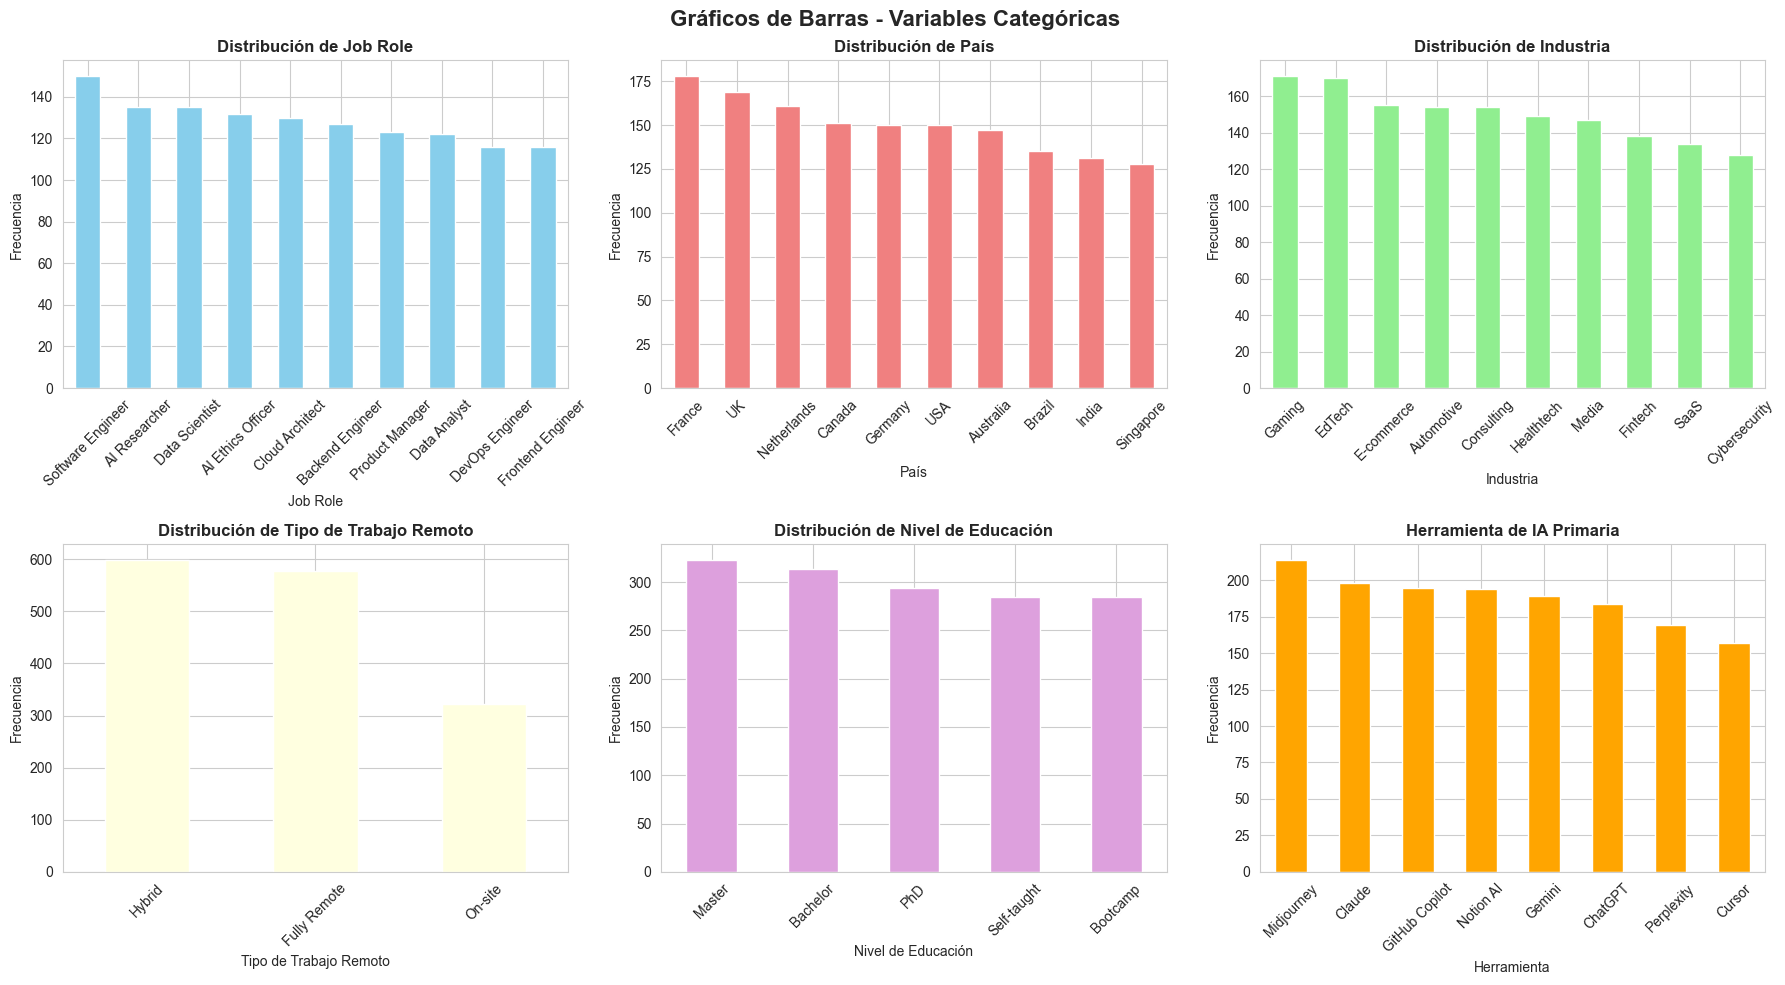

Gráficos de barras creados exitosamente


In [50]:
# Gráficos de barras para variables categóricas
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Gráficos de Barras - Variables Categóricas', fontsize=16, fontweight='bold')

# Job Role
df['job_role'].value_counts().head(10).plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribución de Job Role', fontweight='bold')
axes[0, 0].set_xlabel('Job Role')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].tick_params(axis='x', rotation=45)

# Country
df['country'].value_counts().head(10).plot(kind='bar', ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Distribución de País', fontweight='bold')
axes[0, 1].set_xlabel('País')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].tick_params(axis='x', rotation=45)

# Industry
df['industry'].value_counts().head(10).plot(kind='bar', ax=axes[0, 2], color='lightgreen')
axes[0, 2].set_title('Distribución de Industria', fontweight='bold')
axes[0, 2].set_xlabel('Industria')
axes[0, 2].set_ylabel('Frecuencia')
axes[0, 2].tick_params(axis='x', rotation=45)

# Remote Work Type
df['remote_work_type'].value_counts().plot(kind='bar', ax=axes[1, 0], color='lightyellow')
axes[1, 0].set_title('Distribución de Tipo de Trabajo Remoto', fontweight='bold')
axes[1, 0].set_xlabel('Tipo de Trabajo Remoto')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].tick_params(axis='x', rotation=45)

# Education Level
df['education_level'].value_counts().plot(kind='bar', ax=axes[1, 1], color='plum')
axes[1, 1].set_title('Distribución de Nivel de Educación', fontweight='bold')
axes[1, 1].set_xlabel('Nivel de Educación')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].tick_params(axis='x', rotation=45)

# Primary AI Tool
df['primary_ai_tool'].value_counts().head(10).plot(kind='bar', ax=axes[1, 2], color='orange')
axes[1, 2].set_title('Herramienta de IA Primaria', fontweight='bold')
axes[1, 2].set_xlabel('Herramienta')
axes[1, 2].set_ylabel('Frecuencia')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Gráficos de barras creados exitosamente")


## 14. Tendencias por Años de Experiencia

### Guía para exponer esta sección

**Qué decir:**
- Este bloque analiza cómo evolucionan burnout, satisfacción, productividad y uso de IA según experiencia laboral.
- Te permite explicar si la trayectoria profesional actúa como factor protector o de riesgo.

**Conexión con la problemática:**
- Si el riesgo se concentra en ciertos tramos de experiencia, se pueden diseñar programas de acompañamiento específicos.

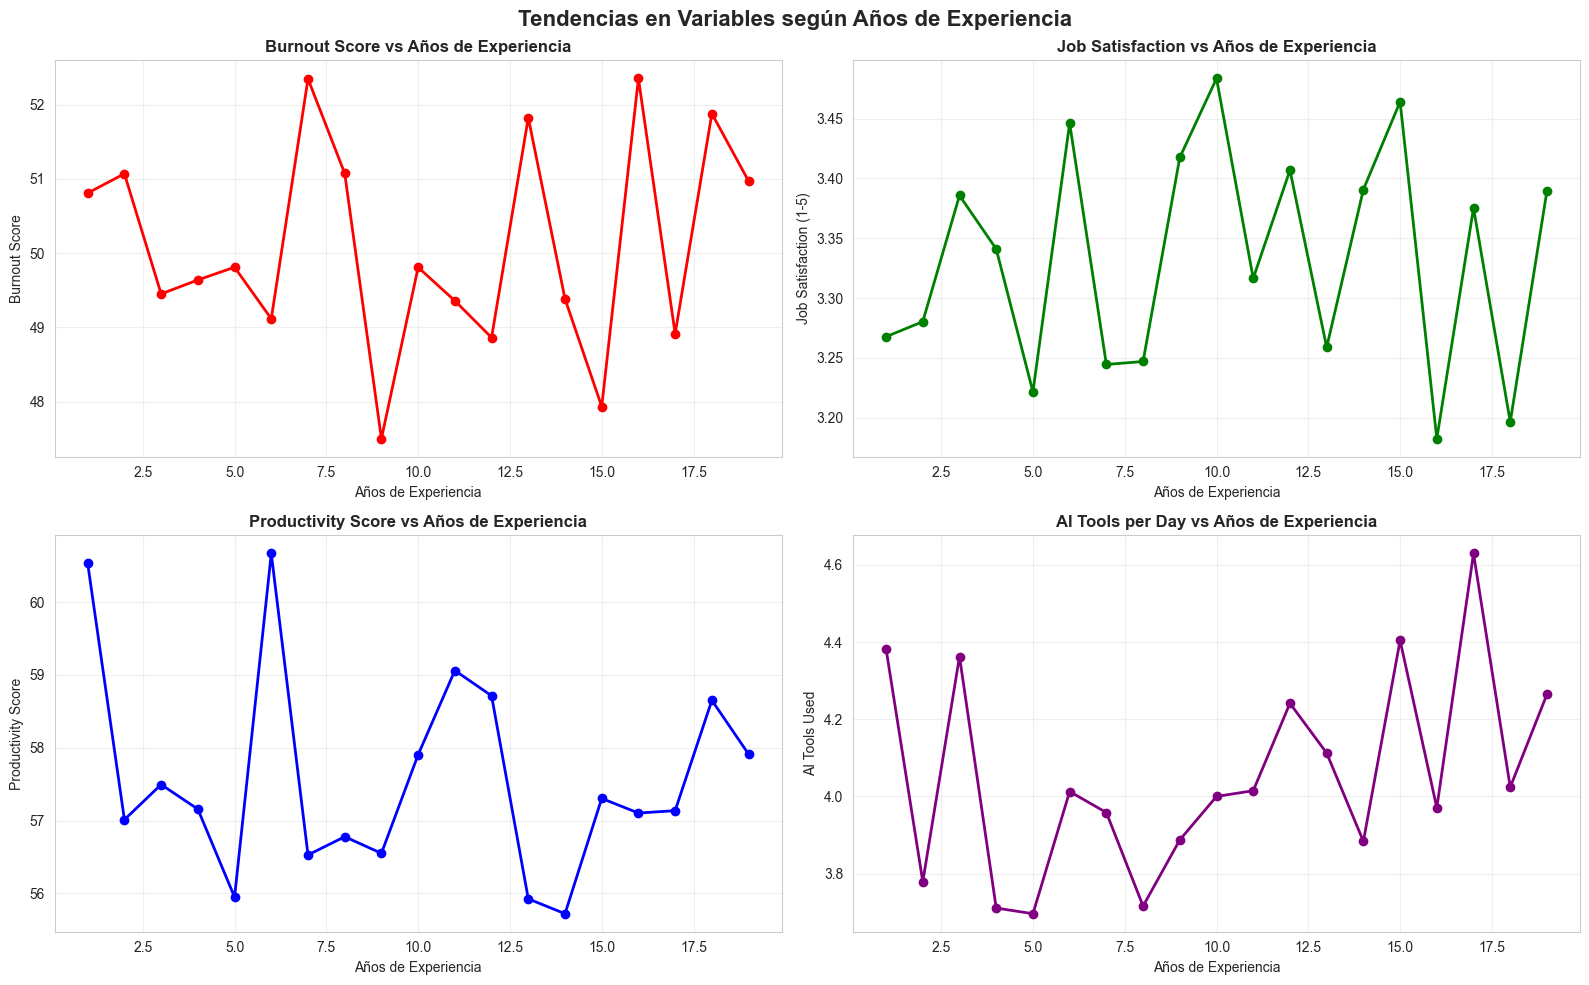

Gráficos de líneas creados exitosamente


In [51]:
# Gráficos de líneas - Tendencias según años de experiencia
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Tendencias en Variables según Años de Experiencia', fontsize=16, fontweight='bold')

# Agrupar por años de experiencia
df_sorted = df.sort_values('years_experience')
experience_groups = df_sorted.groupby('years_experience')

# Burnout Score
burnout_trend = experience_groups['burnout_score'].mean()
axes[0, 0].plot(burnout_trend.index, burnout_trend.values, marker='o', linewidth=2, markersize=6, color='red')
axes[0, 0].set_title('Burnout Score vs Años de Experiencia', fontweight='bold')
axes[0, 0].set_xlabel('Años de Experiencia')
axes[0, 0].set_ylabel('Burnout Score')
axes[0, 0].grid(True, alpha=0.3)

# Job Satisfaction
satisfaction_trend = experience_groups['job_satisfaction_1_5'].mean()
axes[0, 1].plot(satisfaction_trend.index, satisfaction_trend.values, marker='o', linewidth=2, markersize=6, color='green')
axes[0, 1].set_title('Job Satisfaction vs Años de Experiencia', fontweight='bold')
axes[0, 1].set_xlabel('Años de Experiencia')
axes[0, 1].set_ylabel('Job Satisfaction (1-5)')
axes[0, 1].grid(True, alpha=0.3)

# Productivity Score
productivity_trend = experience_groups['productivity_score'].mean()
axes[1, 0].plot(productivity_trend.index, productivity_trend.values, marker='o', linewidth=2, markersize=6, color='blue')
axes[1, 0].set_title('Productivity Score vs Años de Experiencia', fontweight='bold')
axes[1, 0].set_xlabel('Años de Experiencia')
axes[1, 0].set_ylabel('Productivity Score')
axes[1, 0].grid(True, alpha=0.3)

# AI Tools per Day
ai_tools_trend = experience_groups['ai_tools_used_per_day'].mean()
axes[1, 1].plot(ai_tools_trend.index, ai_tools_trend.values, marker='o', linewidth=2, markersize=6, color='purple')
axes[1, 1].set_title('AI Tools per Day vs Años de Experiencia', fontweight='bold')
axes[1, 1].set_xlabel('Años de Experiencia')
axes[1, 1].set_ylabel('AI Tools Used')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Gráficos de líneas creados exitosamente")


## 15. Magnitud del Problema: Riesgo de Attrition y Adopción de IA

### Guía para exponer esta sección

**Qué decir:**
- Los gráficos de pastel muestran la dimensión del riesgo de salida y el contexto de adopción tecnológica.
- Aquí debes enfatizar cuán relevante es el fenómeno en términos de proporción de empleados.

**Conexión con la problemática:**
- Esta sección aterriza el problema del documento en cifras visibles para priorizar decisiones de retención.

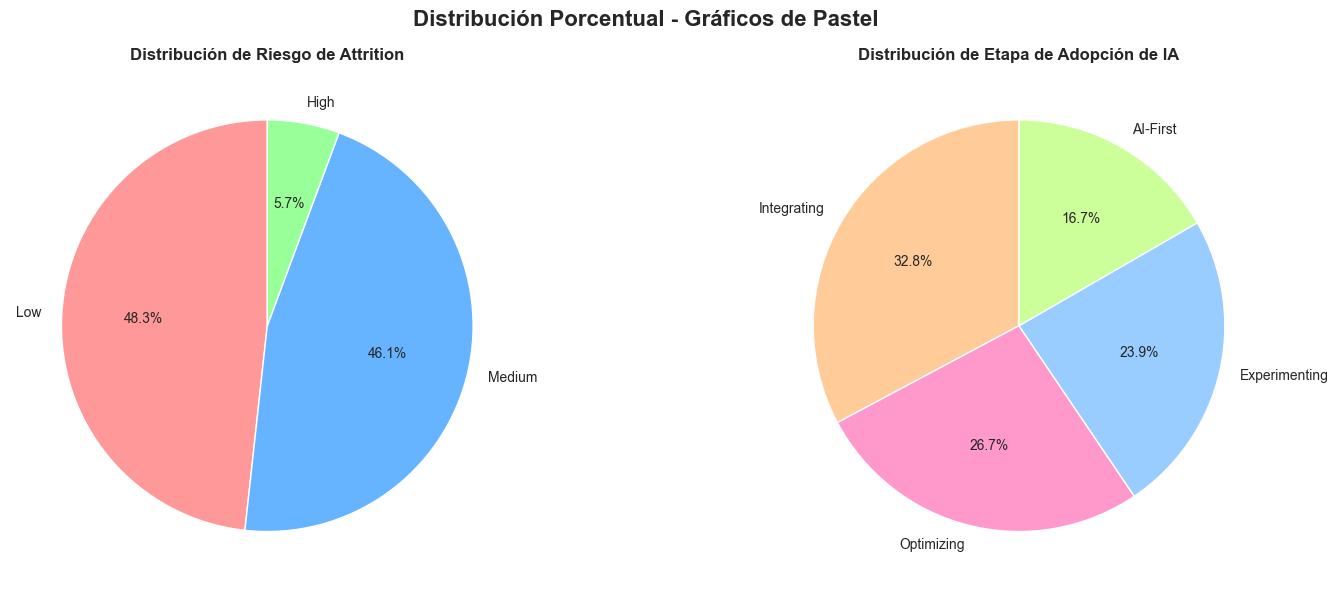

Gráficos de pastel creados exitosamente


In [52]:
# Gráficos de pastel (Pie Charts)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribución Porcentual - Gráficos de Pastel', fontsize=16, fontweight='bold')

# Attrition Risk
attrition_counts = df['attrition_risk'].value_counts()
colors1 = ['#ff9999', '#66b3ff', '#99ff99']
axes[0].pie(attrition_counts.values, labels=attrition_counts.index, autopct='%1.1f%%', 
            colors=colors1, startangle=90)
axes[0].set_title('Distribución de Riesgo de Attrition', fontweight='bold', fontsize=12)

# AI Adoption Stage
adoption_counts = df['ai_adoption_stage'].value_counts()
colors2 = ['#ffcc99', '#ff99cc', '#99ccff', '#ccff99']
axes[1].pie(adoption_counts.values, labels=adoption_counts.index, autopct='%1.1f%%', 
            colors=colors2, startangle=90)
axes[1].set_title('Distribución de Etapa de Adopción de IA', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print("Gráficos de pastel creados exitosamente")


## 16. Relaciones Clave para Explicar Burnout y Deserción

### Guía para exponer esta sección

**Qué decir:**
- Los gráficos de dispersión exploran relaciones entre agotamiento, productividad, salario, temor a reemplazo y aprendizaje en IA.
- Esta es la sección para argumentar hipótesis explicativas con evidencia visual.

**Conexión con la problemática:**
- Identifica combinaciones de variables que pueden funcionar como señales tempranas de riesgo psicosocial y de abandono.

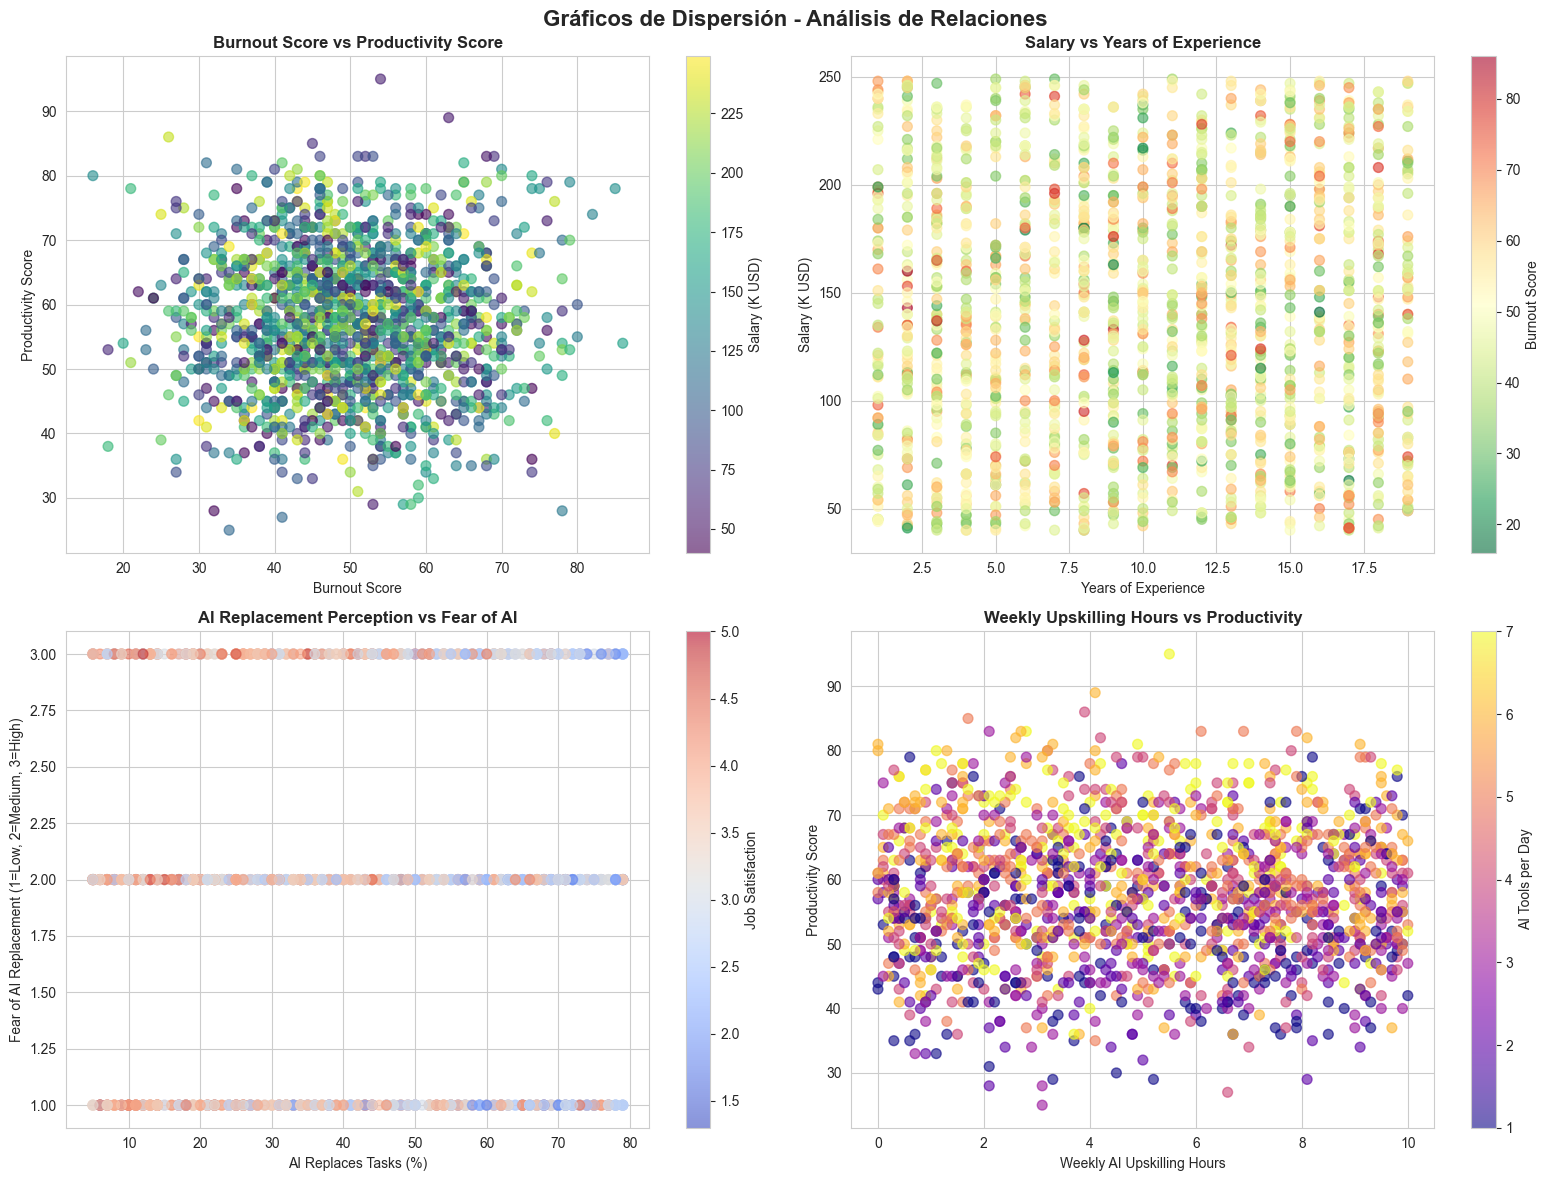

Gráficos de dispersión creados exitosamente


In [53]:
# Gráficos de dispersión
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Gráficos de Dispersión - Análisis de Relaciones', fontsize=16, fontweight='bold')

# Burnout vs Productivity
scatter1 = axes[0, 0].scatter(df['burnout_score'], df['productivity_score'], 
                              c=df['salary_usd_k'], cmap='viridis', s=50, alpha=0.6)
axes[0, 0].set_title('Burnout Score vs Productivity Score', fontweight='bold')
axes[0, 0].set_xlabel('Burnout Score')
axes[0, 0].set_ylabel('Productivity Score')
plt.colorbar(scatter1, ax=axes[0, 0], label='Salary (K USD)')

# Salary vs Years Experience
scatter2 = axes[0, 1].scatter(df['years_experience'], df['salary_usd_k'], 
                              c=df['burnout_score'], cmap='RdYlGn_r', s=50, alpha=0.6)
axes[0, 1].set_title('Salary vs Years of Experience', fontweight='bold')
axes[0, 1].set_xlabel('Years of Experience')
axes[0, 1].set_ylabel('Salary (K USD)')
plt.colorbar(scatter2, ax=axes[0, 1], label='Burnout Score')

# AI Replacement vs Fear of AI
scatter3 = axes[1, 0].scatter(df['ai_replaces_my_tasks_pct'], df['fear_of_ai_replacement'].map({'Low': 1, 'Medium': 2, 'High': 3}), 
                              c=df['job_satisfaction_1_5'], cmap='coolwarm', s=50, alpha=0.6)
axes[1, 0].set_title('AI Replacement Perception vs Fear of AI', fontweight='bold')
axes[1, 0].set_xlabel('AI Replaces Tasks (%)')
axes[1, 0].set_ylabel('Fear of AI Replacement (1=Low, 2=Medium, 3=High)')
plt.colorbar(scatter3, ax=axes[1, 0], label='Job Satisfaction')

# Weekly Upskilling vs Productivity
scatter4 = axes[1, 1].scatter(df['weekly_ai_upskilling_hrs'], df['productivity_score'], 
                              c=df['ai_tools_used_per_day'], cmap='plasma', s=50, alpha=0.6)
axes[1, 1].set_title('Weekly Upskilling Hours vs Productivity', fontweight='bold')
axes[1, 1].set_xlabel('Weekly AI Upskilling Hours')
axes[1, 1].set_ylabel('Productivity Score')
plt.colorbar(scatter4, ax=axes[1, 1], label='AI Tools per Day')

plt.tight_layout()
plt.show()

print("Gráficos de dispersión creados exitosamente")


## 17. Distribución de Factores Críticos

### Guía para exponer esta sección

**Qué decir:**
- Los histogramas permiten ver concentración, asimetrías y posibles extremos en variables sensibles del proyecto.
- Usa este bloque para destacar grupos potencialmente vulnerables.

**Conexión con la problemática:**
- Los valores extremos ayudan a priorizar población objetivo para intervención temprana y seguimiento.

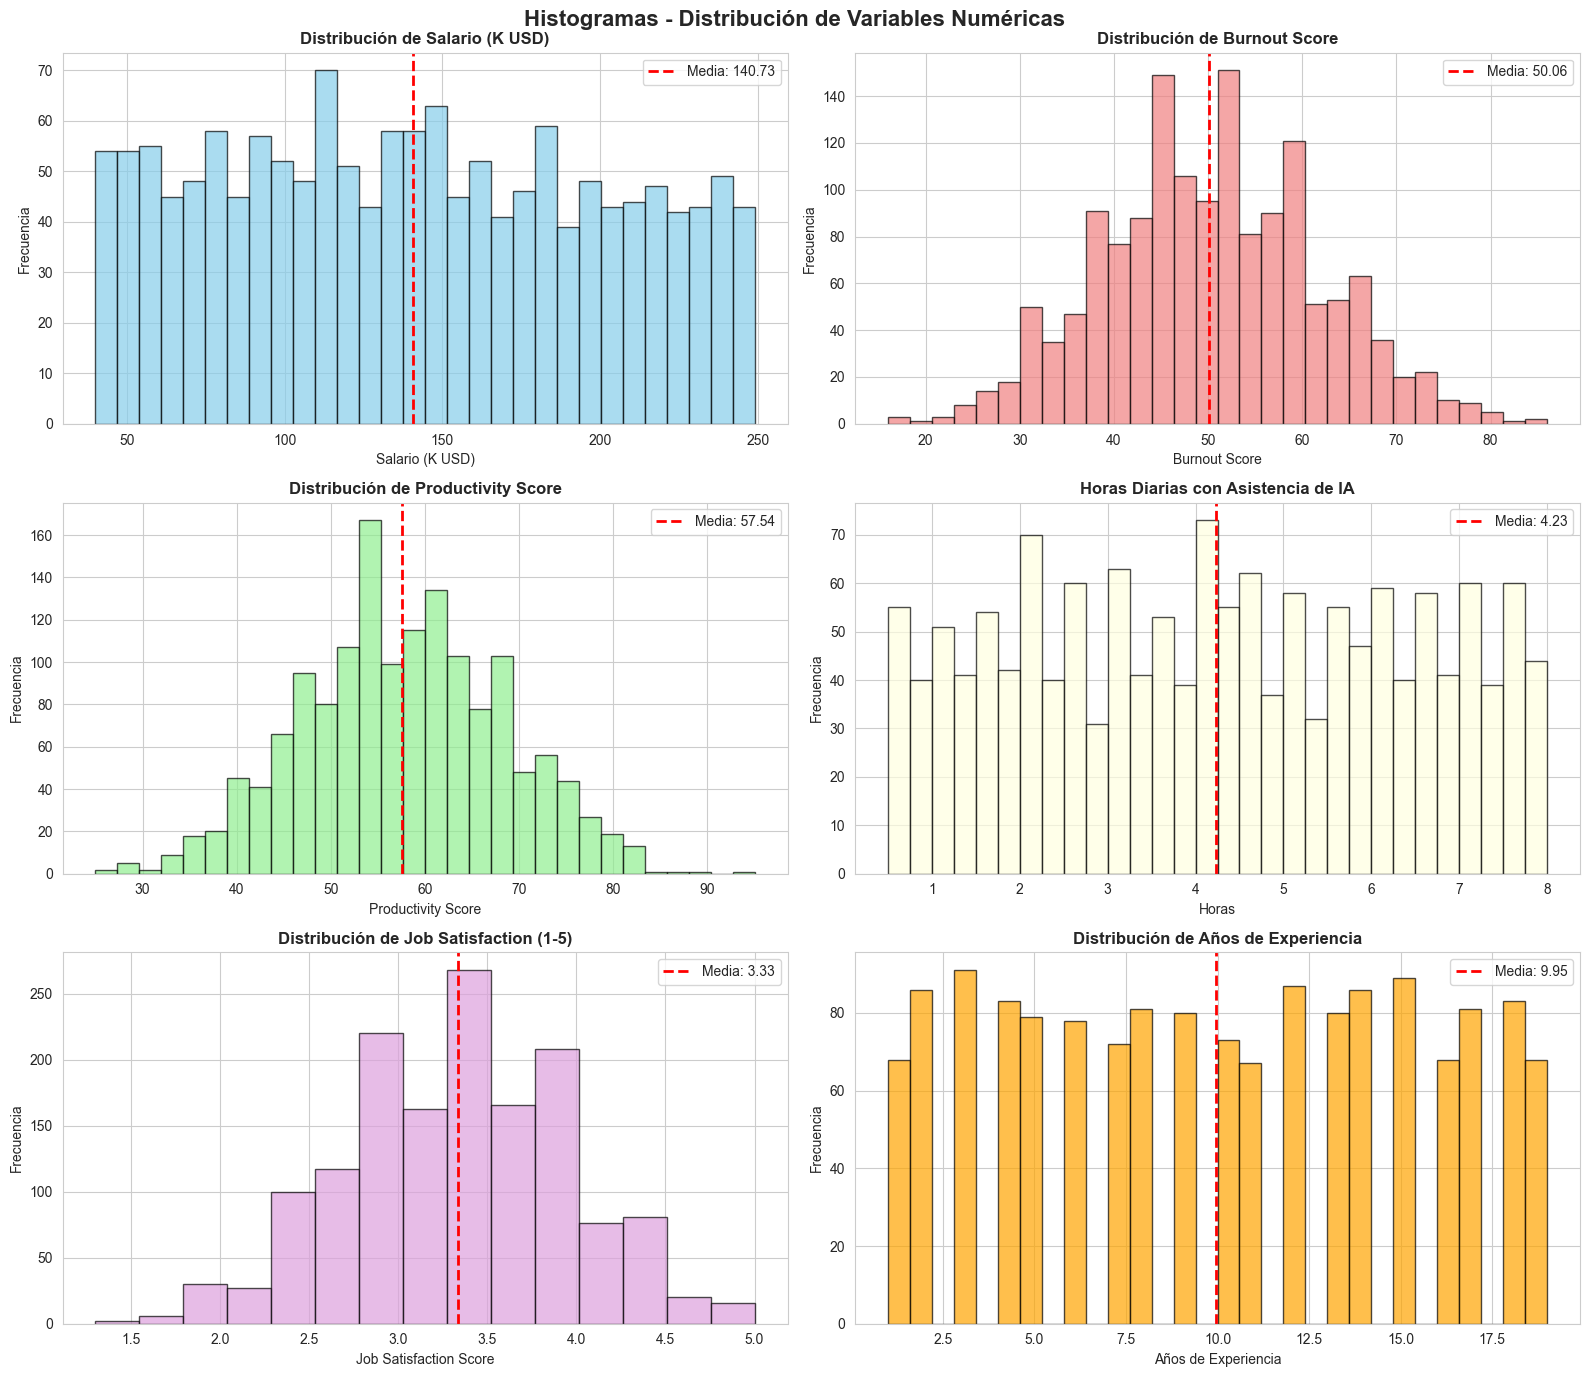

Histogramas creados exitosamente


In [54]:
# Histogramas de variables numéricas
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Histogramas - Distribución de Variables Numéricas', fontsize=16, fontweight='bold')

# Salary
axes[0, 0].hist(df['salary_usd_k'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribución de Salario (K USD)', fontweight='bold')
axes[0, 0].set_xlabel('Salario (K USD)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].axvline(df['salary_usd_k'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["salary_usd_k"].mean():.2f}')
axes[0, 0].legend()

# Burnout Score
axes[0, 1].hist(df['burnout_score'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribución de Burnout Score', fontweight='bold')
axes[0, 1].set_xlabel('Burnout Score')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].axvline(df['burnout_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["burnout_score"].mean():.2f}')
axes[0, 1].legend()

# Productivity Score
axes[1, 0].hist(df['productivity_score'], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribución de Productivity Score', fontweight='bold')
axes[1, 0].set_xlabel('Productivity Score')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].axvline(df['productivity_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["productivity_score"].mean():.2f}')
axes[1, 0].legend()

# Hours with AI Assistance
axes[1, 1].hist(df['hours_with_ai_assistance_daily'], bins=30, color='lightyellow', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Horas Diarias con Asistencia de IA', fontweight='bold')
axes[1, 1].set_xlabel('Horas')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].axvline(df['hours_with_ai_assistance_daily'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["hours_with_ai_assistance_daily"].mean():.2f}')
axes[1, 1].legend()

# Job Satisfaction
axes[2, 0].hist(df['job_satisfaction_1_5'], bins=15, color='plum', edgecolor='black', alpha=0.7)
axes[2, 0].set_title('Distribución de Job Satisfaction (1-5)', fontweight='bold')
axes[2, 0].set_xlabel('Job Satisfaction Score')
axes[2, 0].set_ylabel('Frecuencia')
axes[2, 0].axvline(df['job_satisfaction_1_5'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["job_satisfaction_1_5"].mean():.2f}')
axes[2, 0].legend()

# Years of Experience
axes[2, 1].hist(df['years_experience'], bins=30, color='orange', edgecolor='black', alpha=0.7)
axes[2, 1].set_title('Distribución de Años de Experiencia', fontweight='bold')
axes[2, 1].set_xlabel('Años de Experiencia')
axes[2, 1].set_ylabel('Frecuencia')
axes[2, 1].axvline(df['years_experience'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["years_experience"].mean():.2f}')
axes[2, 1].legend()

plt.tight_layout()
plt.show()

print("Histogramas creados exitosamente")


## 17. Integración de Hallazgos (Vista Ejecutiva)

### Guía para exponer esta sección

**Qué decir:**
- Esta sección integra todo en una sola vista para responder: quién está en riesgo, bajo qué condiciones y con qué patrones.
- Aquí también se compara el burnout según el tamaño de la empresa para ver si la estructura organizacional influye en el agotamiento.
- También se observa cómo cambia la productividad según niveles de riesgo de burnout para conectar bienestar y desempeño.
- Además, se contrasta la productividad con la satisfacción laboral para mostrar si el bienestar percibido se traduce en mejor rendimiento.
- Es la parte más útil para audiencias directivas por su enfoque comparativo y de KPIs.

**Conexión con la problemática:**
- Facilita decisiones transversales: bienestar, liderazgo, formación y estrategia de retención de talento.

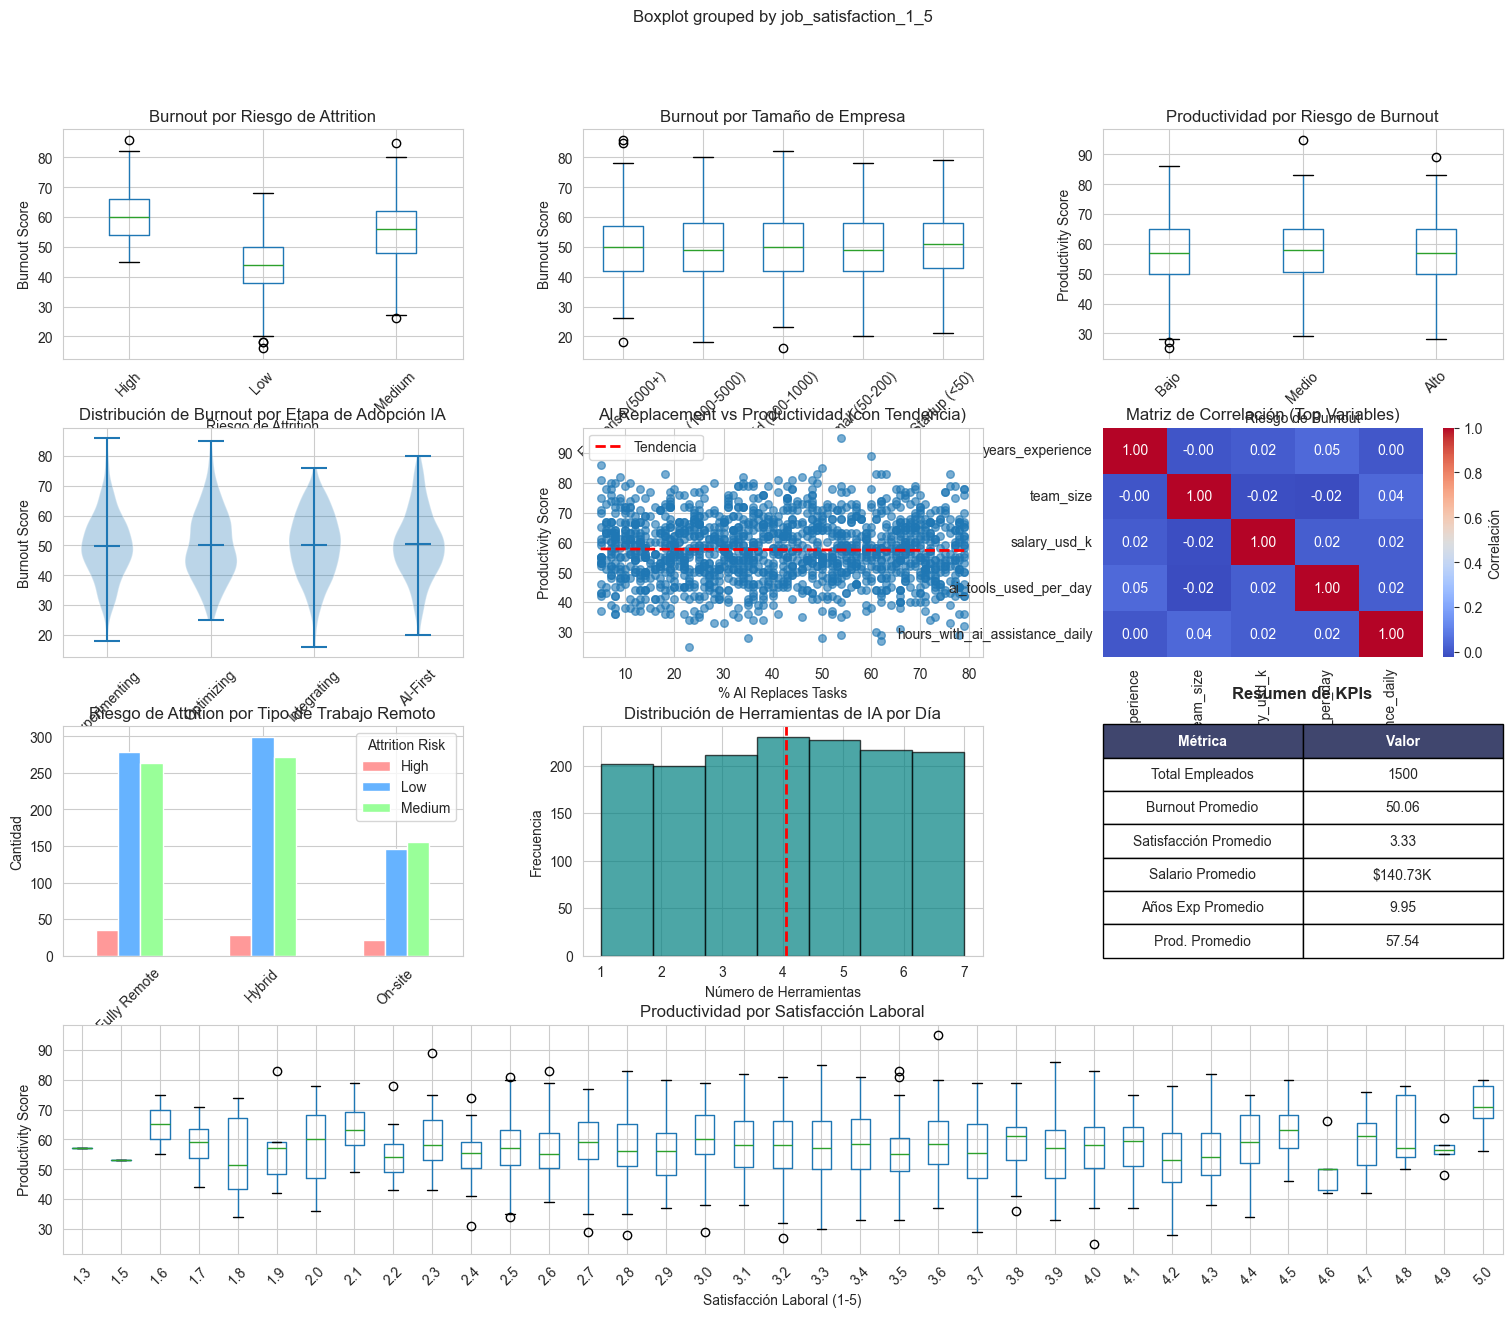

Análisis comparativo con subplots creado exitosamente


In [55]:
# Análisis comparativo con subplots avanzados
fig = plt.figure(figsize=(18, 15))
gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

fig.suptitle('Análisis Comparativo Integrado - Subplots Complejos', fontsize=16, fontweight='bold')

# 1. Box plot - Burnout by Attrition Risk
ax1 = fig.add_subplot(gs[0, 0])
df.boxplot(column='burnout_score', by='attrition_risk', ax=ax1)
ax1.set_title('Burnout por Riesgo de Attrition')
ax1.set_xlabel('Riesgo de Attrition')
ax1.set_ylabel('Burnout Score')
plt.sca(ax1)
plt.xticks(rotation=45)

# 2. Box plot - Burnout by Company Size
ax2 = fig.add_subplot(gs[0, 1])
df.boxplot(column='burnout_score', by='company_size', ax=ax2)
ax2.set_title('Burnout por Tamaño de Empresa')
ax2.set_xlabel('Tamaño de Empresa')
ax2.set_ylabel('Burnout Score')
plt.sca(ax2)
plt.xticks(rotation=45)

# 3. Box plot - Productivity by Burnout Risk Level
ax3 = fig.add_subplot(gs[0, 2])
burnout_bins = pd.qcut(df['burnout_score'], q=3, labels=['Bajo', 'Medio', 'Alto'])
df_burnout_bins = df.copy()
df_burnout_bins['burnout_risk_level'] = burnout_bins
df_burnout_bins.boxplot(column='productivity_score', by='burnout_risk_level', ax=ax3)
ax3.set_title('Productividad por Riesgo de Burnout')
ax3.set_xlabel('Riesgo de Burnout')
ax3.set_ylabel('Productivity Score')
plt.sca(ax3)
plt.xticks(rotation=45)

# 4. Violin plot - Burnout by AI Adoption Stage
ax4 = fig.add_subplot(gs[1, 0])
adoption_stages = df['ai_adoption_stage'].unique()
data_violin = [df[df['ai_adoption_stage'] == stage]['burnout_score'].values for stage in adoption_stages]
ax4.violinplot(data_violin, positions=range(len(adoption_stages)), showmeans=True)
ax4.set_xticks(range(len(adoption_stages)))
ax4.set_xticklabels(adoption_stages, rotation=45)
ax4.set_title('Distribución de Burnout por Etapa de Adopción IA')
ax4.set_ylabel('Burnout Score')

# 5. Scatter + Regression - AI Replacement vs Productivity
ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(df['ai_replaces_my_tasks_pct'], df['productivity_score'], alpha=0.6, s=30)
z = np.polyfit(df['ai_replaces_my_tasks_pct'], df['productivity_score'], 1)
p = np.poly1d(z)
ax5.plot(df['ai_replaces_my_tasks_pct'].sort_values(), p(df['ai_replaces_my_tasks_pct'].sort_values()), 
         "r--", linewidth=2, label='Tendencia')
ax5.set_title('AI Replacement vs Productividad (con Tendencia)')
ax5.set_xlabel('% AI Replaces Tasks')
ax5.set_ylabel('Productivity Score')
ax5.legend()

# 6. Heatmap - Correlación de variables numéricas
ax6 = fig.add_subplot(gs[1, 2])
correlation = df_numericos.corr()
sns.heatmap(correlation.iloc[:5, :5], annot=True, fmt='.2f', cmap='coolwarm', ax=ax6, cbar_kws={'label': 'Correlación'})
ax6.set_title('Matriz de Correlación (Top Variables)')

# 7. Count plot - Attrition Risk by Remote Work Type
ax7 = fig.add_subplot(gs[2, 0])
remote_attrition = pd.crosstab(df['remote_work_type'], df['attrition_risk'])
remote_attrition.plot(kind='bar', ax=ax7, color=['#ff9999', '#66b3ff', '#99ff99'])
ax7.set_title('Riesgo de Attrition por Tipo de Trabajo Remoto')
ax7.set_xlabel('Tipo de Trabajo Remoto')
ax7.set_ylabel('Cantidad')
plt.sca(ax7)
plt.xticks(rotation=45)
ax7.legend(title='Attrition Risk')

# 8. Distribution plot - AI Tools per Day
ax8 = fig.add_subplot(gs[2, 1])
ax8.hist(df['ai_tools_used_per_day'], bins=max(df['ai_tools_used_per_day'].unique()), 
         color='teal', edgecolor='black', alpha=0.7)
ax8.set_title('Distribución de Herramientas de IA por Día')
ax8.set_xlabel('Número de Herramientas')
ax8.set_ylabel('Frecuencia')
ax8.axvline(df['ai_tools_used_per_day'].mean(), color='red', linestyle='--', linewidth=2)

# 9. KPI Summary Table
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')
kpi_data = [
    ['Métrica', 'Valor'],
    ['Total Empleados', f"{len(df)}"],
    ['Burnout Promedio', f"{df['burnout_score'].mean():.2f}"],
    ['Satisfacción Promedio', f"{df['job_satisfaction_1_5'].mean():.2f}"],
    ['Salario Promedio', f"${df['salary_usd_k'].mean():.2f}K"],
    ['Años Exp Promedio', f"{df['years_experience'].mean():.2f}"],
    ['Prod. Promedio', f"{df['productivity_score'].mean():.2f}"]
]
table = ax9.table(cellText=kpi_data, cellLoc='center', loc='center', 
                  colWidths=[0.5, 0.5])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
# Dar formato a la cabecera
for i in range(2):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')
ax9.set_title('Resumen de KPIs', fontweight='bold', pad=20)

# 10. Box plot - Productivity by Job Satisfaction Level
ax10 = fig.add_subplot(gs[3, :])
df.boxplot(column='productivity_score', by='job_satisfaction_1_5', ax=ax10)
ax10.set_title('Productividad por Satisfacción Laboral')
ax10.set_xlabel('Satisfacción Laboral (1-5)')
ax10.set_ylabel('Productivity Score')
plt.sca(ax10)
plt.xticks(rotation=45)

fig.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

print("Análisis comparativo con subplots creado exitosamente")

## 18. Conclusiones para la Exposición y Toma de Decisiones

### Respuesta a la pregunta del proyecto

Con base en el análisis exploratorio, **sí es viable anticipar señales de riesgo de burnout y deserción** a partir de variables laborales, tecnológicas y de satisfacción.

### Guía para exponer esta sección

**Qué decir:**
- Cierra con tres ideas: magnitud del problema, relaciones más fuertes y decisiones accionables.
- Recalca que este EDA no reemplaza un modelo predictivo, pero sí define variables candidatas y prioridades de intervención.

**Conexión con la problemática:**
- Se responde la pregunta del proyecto con evidencia y se propone una ruta de implementación organizacional responsable.

In [56]:
# Cierre ejecutivo orientado a exposición
print("="*90)
print("CIERRE EJECUTIVO: BURNOUT Y RIESGO DE DESERCIÓN")
print("="*90)

# 1) Magnitud del problema
n = len(df)
attrition_dist = df['attrition_risk'].value_counts()
print("\n1) MAGNITUD DEL PROBLEMA")
for category, count in attrition_dist.items():
    pct = (count / n) * 100
    print(f"  - {category}: {count} empleados ({pct:.1f}%)")

print(f"\n  Burnout promedio: {df['burnout_score'].mean():.2f}")
print(f"  Satisfacción promedio (1-5): {df['job_satisfaction_1_5'].mean():.2f}")

# 2) Relación burnout-productividad
corr_bp = df['burnout_score'].corr(df['productivity_score'])
print("\n2) EVIDENCIA CLAVE")
print(f"  - Correlación Burnout vs Productividad: {corr_bp:.3f}")
if corr_bp < 0:
    print("  - Lectura: al aumentar el burnout, tiende a disminuir la productividad.")
elif corr_bp > 0:
    print("  - Lectura: burnout y productividad crecen juntos en este dataset (revisar contexto).")
else:
    print("  - Lectura: no hay relación lineal relevante entre burnout y productividad.")

# 3) Diferencia de burnout por nivel de riesgo de deserción
burnout_by_attrition = df.groupby('attrition_risk')['burnout_score'].mean().sort_values(ascending=False)
print("\n3) BURNOUT SEGÚN RIESGO DE DESERCIÓN")
for level, value in burnout_by_attrition.items():
    print(f"  - {level}: burnout promedio = {value:.2f}")

# 4) Señales por modalidad de trabajo
remote_attrition = pd.crosstab(df['remote_work_type'], df['attrition_risk'])
remote_attrition_pct = remote_attrition.div(remote_attrition.sum(axis=1), axis=0) * 100
print("\n4) RIESGO RELATIVO POR MODALIDAD DE TRABAJO")
for mode in remote_attrition_pct.index:
    top_level = remote_attrition_pct.loc[mode].idxmax()
    top_pct = remote_attrition_pct.loc[mode].max()
    print(f"  - {mode}: predomina '{top_level}' con {top_pct:.1f}%")

# 5) Recomendaciones accionables
print("\n5) RECOMENDACIONES PARA STAKEHOLDERS")
print("  - RRHH: priorizar intervenciones en segmentos con mayor burnout y mayor proporción de riesgo alto.")
print("  - Líderes de equipo: monitorear señales tempranas (satisfacción baja + carga alta + fatiga elevada).")
print("  - Dirección: usar este análisis como base para un modelo predictivo supervisado en la siguiente fase.")

# 6) Límite metodológico
print("\n6) LÍMITE DEL ANÁLISIS ACTUAL")
print("  - Este cuaderno es exploratorio (EDA): identifica patrones, pero no establece causalidad.")
print("  - Para predicción formal, se recomienda entrenar y validar un modelo con métricas (F1, recall, matriz de confusión).")

print("\n" + "="*90)
print("Resultado: la exposición queda alineada con la problemática y orientada a decisión.")
print("="*90)

CIERRE EJECUTIVO: BURNOUT Y RIESGO DE DESERCIÓN

1) MAGNITUD DEL PROBLEMA
  - Low: 724 empleados (48.3%)
  - Medium: 691 empleados (46.1%)
  - High: 85 empleados (5.7%)

  Burnout promedio: 50.06
  Satisfacción promedio (1-5): 3.33

2) EVIDENCIA CLAVE
  - Correlación Burnout vs Productividad: -0.005
  - Lectura: al aumentar el burnout, tiende a disminuir la productividad.

3) BURNOUT SEGÚN RIESGO DE DESERCIÓN
  - High: burnout promedio = 60.80
  - Medium: burnout promedio = 55.05
  - Low: burnout promedio = 44.03

4) RIESGO RELATIVO POR MODALIDAD DE TRABAJO
  - Fully Remote: predomina 'Low' con 48.3%
  - Hybrid: predomina 'Low' con 49.9%
  - On-site: predomina 'Medium' con 48.0%

5) RECOMENDACIONES PARA STAKEHOLDERS
  - RRHH: priorizar intervenciones en segmentos con mayor burnout y mayor proporción de riesgo alto.
  - Líderes de equipo: monitorear señales tempranas (satisfacción baja + carga alta + fatiga elevada).
  - Dirección: usar este análisis como base para un modelo predictivo 